# Sistema de Recomendación para superar los 50.000 USD anuales

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [2]:
url_dataset = "https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv"
total_data = pd.read_csv(url_dataset)

total_data.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
print(f"Filas y columnas: {total_data.shape}")
total_data.info()

Filas y columnas: (32561, 15)
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


PASO 2: Prepocesamiento de datos 

In [ ]:
#Limpiamos valores 
#En este dataset los valores ausentes se han codificado como "?" en lugar de estar vacíos.

for columna in total_data.columns:
    cantidad = (total_data[columna] == "?").sum()
    if cantidad > 0:
        print(f"{columna}: {cantidad} valores '?'")

workclass: 1836 valores '?'
occupation: 1843 valores '?'
native.country: 583 valores '?'


In [5]:
# Sustituimos el símbolo "?" por el valor más frecuente (la moda) de cada columna afectada.

for columna in ["workclass", "occupation", "native.country"]:
    moda = total_data.loc[total_data[columna] != "?", columna].mode()[0]
    total_data[columna] = total_data[columna].replace("?", moda)

print((total_data == "?").sum().sum())

0


In [6]:
#Eliminamos columnas que no aportan valor

total_data = total_data.drop(columns=["fnlwgt"])

total_data = total_data.drop(columns=["education"])

total_data.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [7]:
# La columna "native.country" tiene más de 40 países distintos, la mayoría con muy pocos casos.
# Para no generar decenas de columnas casi vacías al codificarla, la simplificamos a una sola
# columna binaria: si la persona nació en Estados Unidos (1) o no (0).


total_data["is_us"] = (total_data["native.country"] == "United-States").astype(int)
total_data = total_data.drop(columns=["native.country"])

total_data[["is_us"]].value_counts()

is_us
1        29753
0         2808
Name: count, dtype: int64

In [8]:
#Vemos primero como se relacionan algunas variables sociales (educación, sexo) para saber que variables importan
#más

# Creamos una columna auxiliar numérica: 1 si la persona gana más de 50K, 0 si no
total_data["income_binaria"] = (total_data["income"] == ">50K").apply(int)

print("Porcentaje que supera 50K según años de educación:")
print(total_data.groupby("education.num")["income_binaria"].mean().round(2))

Porcentaje que supera 50K según años de educación:
education.num
1     0.00
2     0.04
3     0.05
4     0.06
5     0.05
6     0.07
7     0.05
8     0.08
9     0.16
10    0.19
11    0.26
12    0.25
13    0.41
14    0.56
15    0.73
16    0.74
Name: income_binaria, dtype: float64


In [9]:
# Porcentaje de personas que superan los 50K según el sexo y la raza
print("Porcentaje que supera 50K según sexo:")
print(total_data.groupby("sex")["income_binaria"].mean().round(2))

print("\nPorcentaje que supera 50K según raza:")
print(total_data.groupby("race")["income_binaria"].mean().round(2))

Porcentaje que supera 50K según sexo:
sex
Female    0.11
Male      0.31
Name: income_binaria, dtype: float64

Porcentaje que supera 50K según raza:
race
Amer-Indian-Eskimo    0.12
Asian-Pac-Islander    0.27
Black                 0.12
Other                 0.09
White                 0.26
Name: income_binaria, dtype: float64


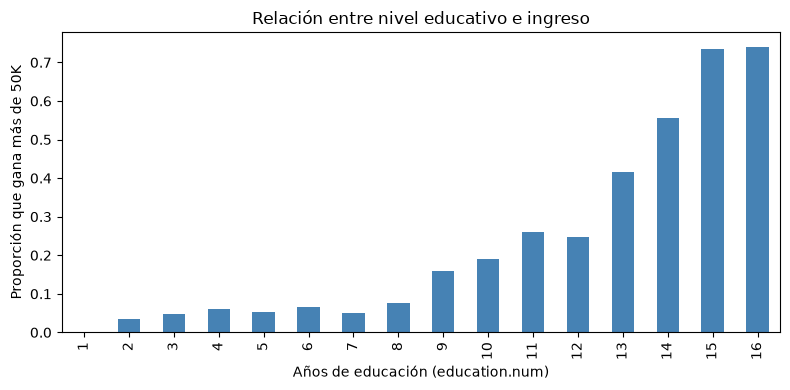

In [10]:
porcentaje_por_educacion = total_data.groupby("education.num")["income_binaria"].mean()

plt.figure(figsize=(8, 4))
porcentaje_por_educacion.plot(kind="bar", color="steelblue")
plt.xlabel("Años de educación (education.num)")
plt.ylabel("Proporción que gana más de 50K")
plt.title("Relación entre nivel educativo e ingreso")
plt.tight_layout()
plt.show()

In [11]:
#Codificamos las variables categóricas y normalizamos las variables numéricas
# Guardamos aparte la variable "income": es la que queremos predecir/mejorar, así que NO debe
# formar parte del vector de características que usaremos para calcular similitudes

income = total_data["income"]

caracteristicas = total_data.drop(columns=["income", "income_binaria"])

# Columnas categóricas que vamos a convertir en columnas 0/1 (codificación one-hot)
columnas_categoricas = ["workclass", "marital.status", "occupation", "relationship", "race", "sex"]

# Columnas numéricas que vamos a normalizar para que todas estén en una escala entre 0 y 1
columnas_numericas = ["age", "education.num", "capital.gain", "capital.loss", "hours.per.week"]

caracteristicas_codificadas = pd.get_dummies(caracteristicas, columns=columnas_categoricas)

escalador = MinMaxScaler()
caracteristicas_codificadas[columnas_numericas] = escalador.fit_transform(caracteristicas_codificadas[columnas_numericas])

print(f"Forma de la matriz de características: {caracteristicas_codificadas.shape}")
caracteristicas_codificadas.head()



Forma de la matriz de características: (32561, 48)


,age,education.num,capital.gain,capital.loss,hours.per.week,is_us,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
0,1.000000,0.533333,0.0,1.000000,0.397959,1,False,False,False,True,...,False,False,False,False,False,False,False,True,True,False
1,0.890411,0.533333,0.0,1.000000,0.173469,1,False,False,False,True,...,False,False,False,False,False,False,False,True,True,False
2,0.671233,0.600000,0.0,1.000000,0.397959,1,False,False,False,True,...,False,True,False,False,False,True,False,False,True,False
3,0.506849,0.200000,0.0,0.895317,0.397959,1,False,False,False,True,...,False,True,False,False,False,False,False,True,True,False
4,0.328767,0.600000,0.0,0.895317,0.397959,1,False,False,False,True,...,True,False,False,False,False,False,False,True,True,False


PASO 3: Definición del problema de recomendación

- **¿Qué se quiere recomendar?** No recomendamos un producto, sino *cambios en el perfil socioeconómico* (más años de educación, más horas trabajadas, otra ocupación...) que acerquen a la persona al grupo de quienes ganan más de 50.000 USD.
- **¿Cuál es el "usuario"?** Cada persona del dataset (o cualquier perfil nuevo que queramos analizar) es un "usuario", representado por un vector con sus características demográficas y socioeconómicas.
- **¿Qué variables definen el perfil de un usuario?** Edad, tipo de trabajo, nivel educativo, estado civil, ocupación, relación familiar, raza, sexo, ganancias/pérdidas de capital, horas trabajadas por semana y si nació en EE. UU. (todas las columnas que acabamos de codificar y normalizar).

Con esto definido, el enfoque que usaremos es el de **filtrado basado en contenido**: representamos a cada persona como un vector de características y, dado el perfil de un usuario nuevo, calculamos su similitud (similitud del coseno) con los perfiles del dataset que ya superan los 50.000 USD. Las personas más similares "marcan el camino" de qué cambios podrían ayudar al usuario a acercarse a ese grupo.

PASO 4: Construcción del sistema de recomendación

In [12]:
X = caracteristicas_codificadas.values

columnas_finales = caracteristicas_codificadas.columns

mascara_mas_50k = (income == ">50K").values
X_mas_50k = X[mascara_mas_50k]

datos_mas_50k = total_data[mascara_mas_50k].reset_index(drop=True)

print(f"Perfiles disponibles para recomendar (ingreso >50K): {X_mas_50k.shape[0]}")

Perfiles disponibles para recomendar (ingreso >50K): 7841


In [13]:
def construir_vector_usuario(perfil):
    fila = pd.DataFrame([perfil])
    fila["is_us"] = (fila["native.country"] == "United-States").astype(int)
    fila = fila.drop(columns=["native.country"])
    fila_codificada = pd.get_dummies(fila, columns=columnas_categoricas)
    fila_codificada[columnas_numericas] = escalador.transform(fila_codificada[columnas_numericas])
    fila_codificada = fila_codificada.reindex(columns=columnas_finales, fill_value=0)

    return fila_codificada.values


In [14]:
def recomendar(perfil, top_n=5):
    vector_usuario = construir_vector_usuario(perfil)
    similitudes = cosine_similarity(vector_usuario, X_mas_50k)[0]
    indices_top = np.argsort(similitudes)[::-1][:top_n]
    similares = datos_mas_50k.iloc[indices_top]
    print(f"Perfiles más similares con ingreso >50K (top {top_n}):")
    print(similares[["age", "education.num", "occupation", "hours.per.week"]].to_string(index=False))

    print("\nRecomendaciones para acercarse a un ingreso >50K:")
    print(f"- Años de educación: tú tienes {perfil['education.num']}, "
          f"la media de tus similares es {similares['education.num'].mean():.1f}")
    print(f"- Horas trabajadas por semana: tú trabajas {perfil['hours.per.week']}, "
          f"la media de tus similares es {similares['hours.per.week'].mean():.1f}")
    print(f"- Ocupación más común entre tus similares: {similares['occupation'].mode()[0]} "
          f"(tu ocupación actual: {perfil['occupation']})")
    print(f"- Estado civil más común entre tus similares: {similares['marital.status'].mode()[0]} "
          f"(tu estado civil actual: {perfil['marital.status']})")

    return similares

PASO 5: Prueba con pefiles de usuarios simulados

In [15]:
# Ejemplo 1: usuario de 25 años, secundaria completa, trabaja medio tiempo
perfil_usuario_1 = {
    "age": 25,
    "workclass": "Private",
    "education.num": 9,
    "marital.status": "Never-married",
    "occupation": "Other-service",
    "relationship": "Own-child",
    "race": "White",
    "sex": "Female",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 20,
    "native.country": "United-States",
}

recomendar(perfil_usuario_1);

Perfiles más similares con ingreso >50K (top 5):
 age  education.num     occupation  hours.per.week
  22             10  Other-service              32
  29             10  Other-service              41
  26             13   Adm-clerical              40
  36             13 Prof-specialty              35
  35             11   Adm-clerical              40

Recomendaciones para acercarse a un ingreso >50K:
- Años de educación: tú tienes 9, la media de tus similares es 11.4
- Horas trabajadas por semana: tú trabajas 20, la media de tus similares es 37.6
- Ocupación más común entre tus similares: Adm-clerical (tu ocupación actual: Other-service)
- Estado civil más común entre tus similares: Never-married (tu estado civil actual: Never-married)


In [16]:
# Ejemplo 2: usuario de 35 años, con estudios universitarios, jornada completa
perfil_usuario_2 = {
    "age": 35,
    "workclass": "Private",
    "education.num": 13,
    "marital.status": "Married-civ-spouse",
    "occupation": "Adm-clerical",
    "relationship": "Husband",
    "race": "White",
    "sex": "Male",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 40,
    "native.country": "United-States",
}

recomendar(perfil_usuario_2);

Perfiles más similares con ingreso >50K (top 5):
 age  education.num   occupation  hours.per.week
  35             13 Adm-clerical              40
  36             13 Adm-clerical              40
  39             13 Adm-clerical              40
  31             13 Adm-clerical              40
  35             12 Adm-clerical              40

Recomendaciones para acercarse a un ingreso >50K:
- Años de educación: tú tienes 13, la media de tus similares es 12.8
- Horas trabajadas por semana: tú trabajas 40, la media de tus similares es 40.0
- Ocupación más común entre tus similares: Adm-clerical (tu ocupación actual: Adm-clerical)
- Estado civil más común entre tus similares: Married-civ-spouse (tu estado civil actual: Married-civ-spouse)


In [17]:
# Ejemplo 3: usuario de 45 años, formación profesional, autónomo
perfil_usuario_3 = {
    "age": 45,
    "workclass": "Self-emp-not-inc",
    "education.num": 11,
    "marital.status": "Divorced",
    "occupation": "Craft-repair",
    "relationship": "Not-in-family",
    "race": "White",
    "sex": "Male",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 45,
    "native.country": "United-States",
}

recomendar(perfil_usuario_3);

Perfiles más similares con ingreso >50K (top 5):
 age  education.num      occupation  hours.per.week
  48              9    Craft-repair              60
  60              9    Craft-repair              50
  33              9    Craft-repair              65
  51             10    Craft-repair               8
  53             14 Exec-managerial              50

Recomendaciones para acercarse a un ingreso >50K:
- Años de educación: tú tienes 11, la media de tus similares es 10.2
- Horas trabajadas por semana: tú trabajas 45, la media de tus similares es 46.6
- Ocupación más común entre tus similares: Craft-repair (tu ocupación actual: Craft-repair)
- Estado civil más común entre tus similares: Divorced (tu estado civil actual: Divorced)
